# Idealized QuaCCAToo models for the Abelian and Non-Abelian protocols

This notebook follows *Geometric Phases in NV Centers: Abelian and Non-Abelian Protocols Using Hyperfine-Engineered Dark Subspaces*. It deliberately uses abstract basis states and only QuaCCAToo's `QSys` and `Rabi` experiment objects; the NV-specific mapping is left for a later step.

QuaCCAToo stores Hamiltonians in MHz and evolves them against time in microseconds. The paper's angular frequencies are therefore converted with $\Omega_{\mathrm{angular}}=2\pi\Omega_{\mathrm{MHz}}$ whenever an analytic expression uses radians.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from qutip import Qobj, basis, ket2dm, qeye, sigmax, sigmay, sigmaz

# Make the local QuaCCAToo checkout importable even if it is not installed editable.
QUACCatoo_ROOT = Path.cwd() / "QuaCCAToo"
if str(QUACCatoo_ROOT) not in sys.path:
    sys.path.insert(0, str(QUACCatoo_ROOT))

from quaccatoo import QSys, Rabi, Analysis

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})

# Abelian

## Single driven two-level system

Equation (1) is

$$H_{\rm rot}(t)=\frac{1}{2}\left[\Delta\sigma_z+\Omega\cos\phi(t)\sigma_x+\Omega\sin\phi(t)\sigma_y\right].$$

The helper cells below isolate the phase envelope, the `QSys`/`Rabi` construction, and the visualization. `Rabi` supplies the time-dependent Schrödinger evolution; the two quadratures implement the programmed microwave phase.

In [2]:
def smooth_phase(t_us, loop_time_us):
    '''Equation (10): a 0 -> 2*pi phase winding with zero endpoint slope.'''
    t_us = np.asarray(t_us)
    x = np.clip(t_us / loop_time_us, 0.0, 1.0)
    return 2 * np.pi * np.sin(np.pi * x / 2) ** 2
# TODO : add noise based on literature

    # mod_t = np.where(t_us == 0, 1e-12, t_us)
    # return mod_t / mod_t

In [3]:
def build_abelian_rabi(
        observable = sigmaz(),
        loop_time_us=20.0, 
        delta_mhz=0.05, 
        omega_mhz=0.20, 
        samples=1201):
    '''Create the ideal two-level phase-winding experiment with QSys and Rabi.'''
    ket_g, ket_e = basis(2, 0), basis(2, 1)
    observable = observable
    system = QSys(
        H0=0.5 * delta_mhz * sigmaz(),
        rho0=ket_g,
        observable=observable,
        units_H0="MHz",
    )

    # QuaCCAToo passes 2*pi*t_us to QuTiP. Convert back to microseconds
    # before evaluating the programmed laboratory phase.
    def x_quadrature(t, **kwargs):
        return np.cos(smooth_phase(t / (2 * np.pi), loop_time_us))

    def y_quadrature(t, **kwargs):
        return np.sin(smooth_phase(t / (2 * np.pi), loop_time_us))
        
    experiment = Rabi(
        pulse_duration=np.linspace(0.0, loop_time_us, samples),
        system=system,
        h1=[0.5 * omega_mhz * sigmax(), 0.5 * omega_mhz * sigmay()],
        pulse_shape=[x_quadrature, y_quadrature],
        options={"nsteps": 10000, "atol": 1e-9, "rtol": 1e-7},
    )
    return system, experiment

(<Figure size 840x600 with 2 Axes>,
 array([<Axes: ylabel='$\\phi(t)$ (rad)'>,
        <Axes: xlabel='Time ($\\mu$s)', ylabel='Quadrature'>], dtype=object))

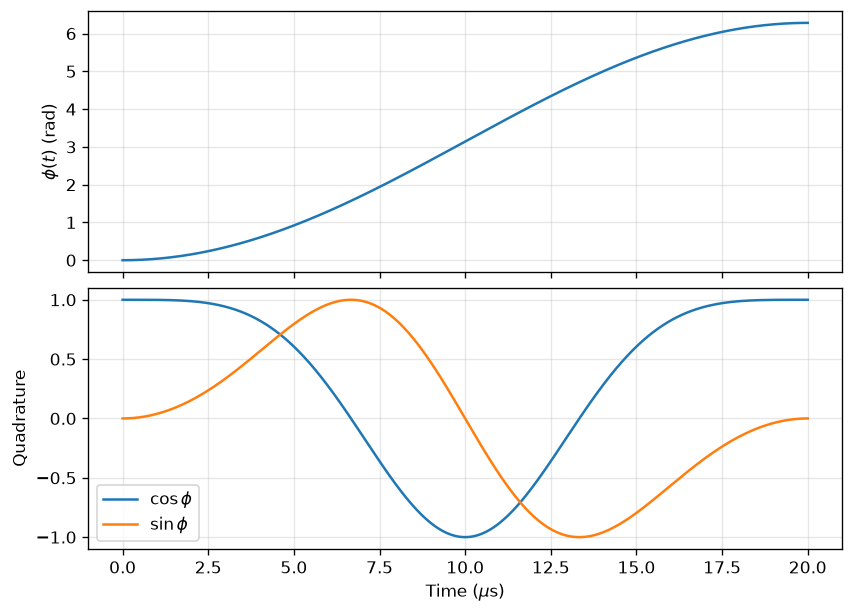

In [4]:
def plot_abelian_drive(loop_time_us=20.0, samples=1001):
    '''Plot the programmed phase and its in-phase/quadrature controls.'''
    t_us = np.linspace(0.0, loop_time_us, samples)
    phase = smooth_phase(t_us, loop_time_us)
    fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True, constrained_layout=True)
    axes[0].plot(t_us, phase)
    axes[0].set_ylabel(r"$\phi(t)$ (rad)")
    axes[1].plot(t_us, np.cos(phase), label=r"$\cos\phi$")
    axes[1].plot(t_us, np.sin(phase), label=r"$\sin\phi$")
    axes[1].set(xlabel=r"Time ($\mu$s)", ylabel="Quadrature")
    axes[1].legend()
    return fig, axes

# observable = [ket2dm(basis(2, 0)), ket2dm(basis(2, 1))]
observable = sigmaz()
abelian_system, abelian_rabi = build_abelian_rabi(observable)
plot_abelian_drive()

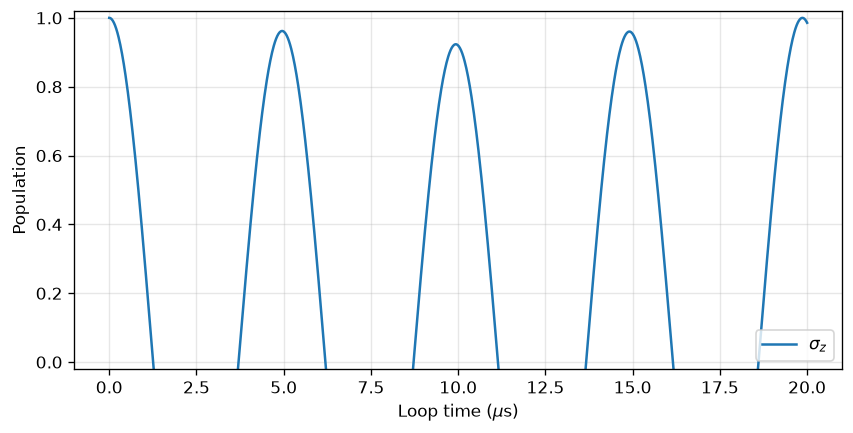

In [5]:
# Run this cell to inspect the ideal Abelian population evolution.
abelian_rabi.run()

fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
if type(abelian_rabi.results) == list:
    for result in abelian_rabi.results:
        ax.plot(abelian_rabi.variable, result)#, label=r"$P_g$")
        # ax.plot(abelian_rabi.variable, abelian_rabi.results[1])#, label=r"$P_e$")

else:
    ax.plot(abelian_rabi.variable, abelian_rabi.results, label=r"$\sigma_z$")

ax.set(xlabel=r"Loop time ($\mu$s)", ylabel="Population", ylim=(-0.02, 1.02))
ax.legend()

In [6]:
abelian_analysis = Analysis(abelian_rabi)

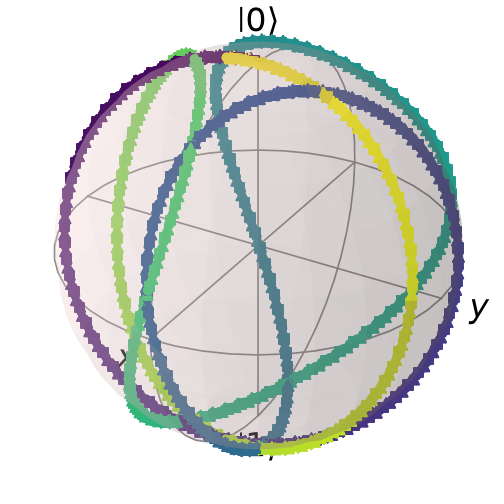

In [7]:
abelian_analysis.plot_bloch()

# Non-Abelian

## Ideal four-level tripod with unequal leg amplitudes

Use the ordered basis
$\{|g_-\rangle,|g_0\rangle,|g_+\rangle,|e\rangle\}$ and the Hamiltonian

$$H(t)=\frac{1}{2}\sum_{m\in\{-,0,+\}}\Omega_m
\left[e^{-i\phi_m(t)}|e\rangle\langle g_m|+
e^{i\phi_m(t)}|g_m\rangle\langle e|\right]. + h.c$$

`TRIPOD_XY` below contains **coupling operators**, not projection operators. The projectors $|g_m\rangle\langle g_m|$ and $|e\rangle\langle e|$ are constructed later only as observables, so `Rabi.results` contains the four populations.

The complex coupling on each leg is separated into two Hermitian quadratures:

$$X_m=\frac{|e\rangle\langle g_m|+|g_m\rangle\langle e|}{2},\qquad
Y_m=\frac{-i|e\rangle\langle g_m|+i|g_m\rangle\langle e|}{2}.$$

Then $\Omega_m[\cos\phi_m X_m+\sin\phi_m Y_m]$ is precisely the $m$ th term of the tripod Hamiltonian. Each $\Omega_m$ is independent.

In [8]:
g_minus, g_zero, g_plus, ancilla = [basis(4, index) for index in range(4)]
ground_kets = (g_minus, g_zero, g_plus)
state_labels = (r"$g_-$", r"$g_0$", r"$g_+$", r"$e$")


def tripod_quadratures(ground_ket):
    '''Return the Hermitian X/Y coupling operators for one tripod leg.'''
    transition = ancilla * ground_ket.dag()  # |e><g_m|
    x_op = 0.5 * (transition + transition.dag())
    y_op = 0.5 * (-1j * transition + 1j * transition.dag())
    return x_op, y_op


TRIPOD_XY = [tripod_quadratures(ket) for ket in ground_kets]
BARE_PROJECTORS = [ket2dm(ket) for ket in (*ground_kets, ancilla)]

In [9]:
def validate_omega_legs(omega_legs_mhz):
    '''Validate and return (Omega_-, Omega_0, Omega_+) in MHz.'''
    omega_legs_mhz = np.asarray(omega_legs_mhz, dtype=float)
    if omega_legs_mhz.shape != (3,) or np.any(omega_legs_mhz <= 0):
        raise ValueError("omega_legs_mhz must contain three positive values")
    return omega_legs_mhz


def omega_total(omega_legs_mhz):
    '''Return sqrt(Omega_-^2 + Omega_0^2 + Omega_+^2) in MHz.'''
    return np.linalg.norm(validate_omega_legs(omega_legs_mhz))

In [10]:
def tripod_dark_states(omega_legs_mhz=(0.16, 0.20, 0.24), phases=(0.0, 0.0, 0.0)):
    '''Equations (5)-(6) for arbitrary positive leg amplitudes.'''
    om_minus, om_zero, om_plus = validate_omega_legs(omega_legs_mhz)
    phi_minus, phi_zero, phi_plus = np.asarray(phases, dtype=float)
    norm_minus_zero = np.hypot(om_minus, om_zero)
    omega_tot = omega_total(omega_legs_mhz)

    d1 = (
        om_zero * np.exp(-1j * phi_zero) * g_minus
        - om_minus * np.exp(-1j * phi_minus) * g_zero
    ) / norm_minus_zero
    d2 = (
        om_plus * np.exp(-1j * phi_plus)
        * (om_minus * np.exp(1j * phi_minus) * g_minus
           + om_zero * np.exp(1j * phi_zero) * g_zero)
        - norm_minus_zero**2 * g_plus
    ) / (omega_tot * norm_minus_zero)
    return d1.unit(), d2.unit()

def tripod_bright_state(omega_legs_mhz=(0.16, 0.20, 0.24), phases=(0.0, 0.0, 0.0)):
    '''Equation (4) for arbitrary positive leg amplitudes'''

    om_arr = validate_omega_legs(omega_legs_mhz)
    phi_arr = np.asarray(phases, dtype=float)
    omega_tot = omega_total(omega_legs_mhz)

    bright_state = basis(4, 0) * 0 # start with a null ket in the space

    for om, phi, g in zip(om_arr, phi_arr, ground_kets):
        bright_state += om * np.exp(1j * phi) * g

    return bright_state / omega_tot

def choose_init_state(state : str, omega_legs_mhz, phases):
    '''a helper function to choose the desired state, state can only be either B, D1, or D2'''

    if state == 'B':
        return tripod_bright_state(omega_legs_mhz, phases)
    elif state == 'D1':
        return tripod_dark_states(omega_legs_mhz, phases)[0]
    elif state == 'D2':
        return tripod_dark_states(omega_legs_mhz, phases)[1]
    else:
        raise KeyError("state can only take the values 'B', 'D1', 'D2'")


In [11]:
def loop_phases(t_us, loop_time_us, loop):
    '''Return (phi_-, phi_0, phi_+) for loop C1 or C2.'''
    if loop not in {"C1", "C2"}:
        raise ValueError("loop must be 'C1' or 'C2'")
    phases = np.zeros(3)
    wound_leg = 0 if loop == "C1" else 2
    phases[wound_leg] = smooth_phase(t_us, loop_time_us)
    return phases

## Validate the programmed phases for $C_1$ and $C_2$

The two loops use the same smooth winding

$$\phi(t)=2\pi\sin^2\left(\frac{\pi t}{2T}\right),$$

but apply it to different tripod legs. For $C_1$, only $\phi_-$ winds; for $C_2$, only $\phi_+$ winds. The plots and checks below use `loop_phases()`, so they display exactly the phases supplied to `build_tripod_rabi()`.

C1: start=[0. 0. 0.], end=[6.283185 0.       0.      ], endpoint rates=(7.752e-04, 7.752e-04) rad/us
C2: start=[0. 0. 0.], end=[0.       0.       6.283185], endpoint rates=(7.752e-04, 7.752e-04) rad/us


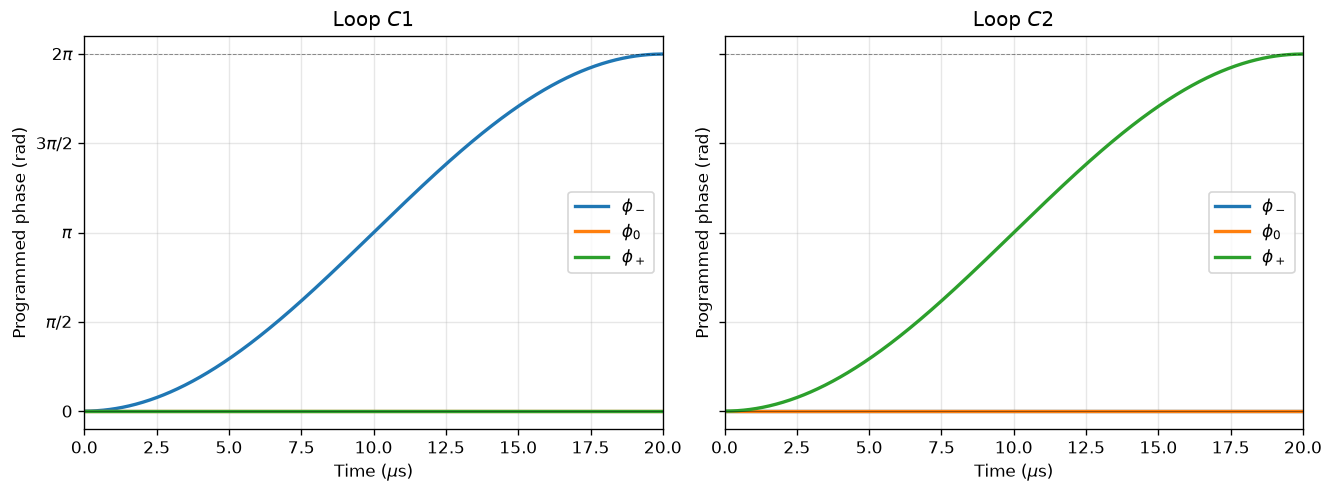

In [12]:
def sample_loop_phases(loop, loop_time_us=20.0, samples=1001):
    '''Evaluate all three programmed phases over one loop.'''
    time_us = np.linspace(0.0, loop_time_us, samples)
    phases = np.array([
        loop_phases(t_us, loop_time_us, loop)
        for t_us in time_us
    ])
    return time_us, phases


def plot_loop_phases(loop_time_us=20.0, samples=1001):
    '''Plot phi_-, phi_0, and phi_+ for loops C1 and C2.'''
    labels = (r"$\phi_-$", r"$\phi_0$", r"$\phi_+$")
    colors = ("tab:blue", "tab:orange", "tab:green")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, constrained_layout=True)

    phase_data = {}
    for ax, loop in zip(axes, ("C1", "C2")):
        time_us, phases = sample_loop_phases(loop, loop_time_us, samples)
        phase_data[loop] = {"time_us": time_us, "phases": phases}

        for leg, (label, color) in enumerate(zip(labels, colors)):
            ax.plot(time_us, phases[:, leg], lw=2, color=color, label=label)

        ax.axhline(0.0, color="k", lw=0.6, alpha=0.4)
        ax.axhline(2 * np.pi, color="k", lw=0.6, ls="--", alpha=0.4)
        ax.set(
            title=rf"Loop ${loop}$",
            xlabel=r"Time ($\mu$s)",
            ylabel="Programmed phase (rad)",
            xlim=(0.0, loop_time_us),
        )
        ax.set_yticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
        ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
        ax.legend()

    return fig, axes, phase_data


def sample_loop_order_phases(order, loop_time_us=20.0, samples_per_loop=1001):
    '''Concatenate the exact programmed phases for two consecutive loops.'''
    if tuple(order) not in {("C1", "C2"), ("C2", "C1")}:
        raise ValueError("order must be ('C1','C2') or ('C2','C1')")

    all_times = []
    all_phases = []
    for sequence_index, loop in enumerate(order):
        local_time, phases = sample_loop_phases(loop, loop_time_us, samples_per_loop)
        start = 0 if sequence_index == 0 else 1
        all_times.append(local_time[start:] + sequence_index * loop_time_us)
        all_phases.append(phases[start:])

    return np.concatenate(all_times), np.concatenate(all_phases, axis=0)


def plot_loop_order_phases(loop_time_us=20.0, samples_per_loop=1001):
    '''Plot phases over the complete C1->C2 and C2->C1 sequences.'''
    labels = (r"$\phi_-$", r"$\phi_0$", r"$\phi_+$")
    colors = ("tab:blue", "tab:orange", "tab:green")
    orders = (("C1", "C2"), ("C2", "C1"))
    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, sharey=True,
                             constrained_layout=True)
    sequence_data = {}

    for ax, order in zip(axes, orders):
        time_us, phases = sample_loop_order_phases(
            order, loop_time_us, samples_per_loop
        )
        key = f"{order[0]}_then_{order[1]}"
        sequence_data[key] = {"time_us": time_us, "phases": phases, "order": order}

        for leg, (label, color) in enumerate(zip(labels, colors)):
            ax.plot(time_us, phases[:, leg], lw=2, color=color, label=label)

        ax.axvline(loop_time_us, color="k", ls="--", lw=1.2,
                   label="loop boundary")
        ax.axhline(2 * np.pi, color="k", ls=":", lw=0.7, alpha=0.5)
        ax.text(loop_time_us / 2, 2.08 * np.pi, rf"${order[0]}$", ha="center")
        ax.text(1.5 * loop_time_us, 2.08 * np.pi, rf"${order[1]}$", ha="center")
        ax.set(
            title=rf"${order[0]}\rightarrow {order[1]}$ phase sequence",
            ylabel="Programmed phase (rad)",
            xlim=(0.0, 2 * loop_time_us),
            ylim=(-0.15, 2.25 * np.pi),
        )
        ax.set_yticks([0, np.pi / 2, np.pi, 3 * np.pi / 2, 2 * np.pi])
        ax.set_yticklabels(["0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])
        ax.legend(loc="center right", ncol=2)

    axes[-1].set_xlabel(r"Sequence time ($\mu$s)")
    fig.suptitle(r"The $2\pi\rightarrow0$ boundary reset is continuous modulo $2\pi$")
    return fig, axes, sequence_data


phase_validation_fig, phase_validation_axes, phase_validation_data = plot_loop_phases()

# Numerical checks of the intended paths.
for loop, wound_leg in (("C1", 0), ("C2", 2)):
    time_us = phase_validation_data[loop]["time_us"]
    phases = phase_validation_data[loop]["phases"]
    stationary_legs = [leg for leg in range(3) if leg != wound_leg]
    phase_rate = np.gradient(phases[:, wound_leg], time_us)

    assert np.allclose(phases[0], 0.0)
    assert np.isclose(phases[-1, wound_leg], 2 * np.pi)
    assert np.allclose(phases[:, stationary_legs], 0.0)
    assert np.all(np.diff(phases[:, wound_leg]) >= -1e-12)
    assert np.isclose(phase_rate[0], 0.0, atol=2e-3)
    assert np.isclose(phase_rate[-1], 0.0, atol=2e-3)

    print(
        f"{loop}: start={phases[0]}, end={np.round(phases[-1], 6)}, "
        f"endpoint rates=({phase_rate[0]:.3e}, {phase_rate[-1]:.3e}) rad/us"
    )

In [13]:
def build_tripod_rabi(
    loop,
    rho0,
    loop_time_us=20.0,
    omega_legs_mhz=(0.16, 0.20, 0.24),
    samples=1201,
):
    '''Construct one C1 or C2 loop using independent leg amplitudes.'''
    omega_legs_mhz = validate_omega_legs(omega_legs_mhz)
    if loop not in {"C1", "C2"}:
        raise ValueError("loop must be 'C1' or 'C2'")

    system = QSys(
        H0=0.0 * qeye(4),
        rho0=rho0,
        observable=BARE_PROJECTORS,
        units_H0="MHz",
    )

    h1, pulse_shapes = [], []
    for leg, (omega_mhz, (x_op, y_op)) in enumerate(zip(omega_legs_mhz, TRIPOD_XY)):
        def cos_coeff(t, leg=leg, **kwargs):
            t_us = t / (2 * np.pi)  # QuaCCAToo supplies 2*pi*t
            phases = loop_phases(t_us, loop_time_us, loop)
            return np.cos(phases[leg])

        def sin_coeff(t, leg=leg, **kwargs):
            t_us = t / (2 * np.pi)
            phases = loop_phases(t_us, loop_time_us, loop)
            return np.sin(phases[leg])

        # This leg's own Omega multiplies both of its quadratures.
        h1.extend([omega_mhz * x_op, omega_mhz * y_op])
        pulse_shapes.extend([cos_coeff, sin_coeff])

    experiment = Rabi(
        pulse_duration=np.linspace(0.0, loop_time_us, samples),
        system=system,
        h1=h1,
        pulse_shape=pulse_shapes,
        options={"nsteps": 20000, "atol": 1e-9, "rtol": 1e-7},
    )
    return experiment

## Consecutive loops and order swapping

The notation below avoids an easy ambiguity:

- `("C1", "C2")` means **apply $C_1$ first, then $C_2$**, so the final state is $U_{C_2}U_{C_1}|\psi_0\rangle$.
- `("C2", "C1")` means **apply $C_2$ first, then $C_1$**, giving $U_{C_1}U_{C_2}|\psi_0\rangle$.

The final state from the first `Rabi` object becomes `rho0` for the second. This is how the two time-dependent Hamiltonian loops are genuinely run consecutively rather than compared as unrelated simulations.

In [14]:
def run_loop_sequence(
    order=("C1", "C2"),
    rho0=None,
    loop_time_us=20.0,
    omega_legs_mhz=(0.16, 0.20, 0.24),
    samples_per_loop=1201,
):
    '''Run two loops consecutively and join their population histories.'''
    omega_legs_mhz = validate_omega_legs(omega_legs_mhz)
    if tuple(order) not in {("C1", "C2"), ("C2", "C1")}:
        raise ValueError("order must be ('C1','C2') or ('C2','C1')")
    if rho0 is None:
        rho0 = tripod_dark_states(omega_legs_mhz)[0]

    experiments = []
    current_state = rho0
    all_times, all_populations = [], []

    for sequence_index, loop in enumerate(order):
        experiment = build_tripod_rabi(
            loop=loop,
            rho0=current_state,
            loop_time_us=loop_time_us,
            omega_legs_mhz=omega_legs_mhz,
            samples=samples_per_loop,
        )
        experiment.run()
        experiments.append(experiment)
        current_state = experiment.rho[-1]

        start = 0 if sequence_index == 0 else 1
        all_times.append(experiment.variable[start:] + sequence_index * loop_time_us)
        all_populations.append(np.asarray(experiment.results)[:, start:])

    return {
        "order": tuple(order),
        "experiments": experiments,
        "time_us": np.concatenate(all_times),
        "populations": np.concatenate(all_populations, axis=1),
        "final_state": current_state,
    }

In [15]:
def dark_coordinates(state, omega_legs_mhz):
    '''Return amplitudes <D1|psi>, <D2|psi> in the fixed initial dark basis.'''
    d1, d2 = tripod_dark_states(omega_legs_mhz, phases=(0.0, 0.0, 0.0))
    if not state.isket:
        raise ValueError("This ideal phase diagnostic expects a ket state")
    return np.array([d1.overlap(state), d2.overlap(state)], dtype=complex)


def relative_dark_phase(state, omega_legs_mhz, cutoff=1e-10):
    '''Gauge-invariant phase arg(<D2|psi>/<D1|psi>), when both amplitudes are nonzero.'''
    amplitudes = dark_coordinates(state, omega_legs_mhz)
    if np.min(np.abs(amplitudes)) < cutoff:
        return np.nan
    return np.angle(amplitudes[1] / amplitudes[0])

In [16]:
def compare_loop_orders(
    initial_state = None,
    omega_legs_mhz=(0.16, 0.20, 0.24),
    loop_time_us=20.0,
    samples_per_loop=1201,
    display_phase_plots=False,
):
    '''Run C1->C2 and C2->C1 from the same initial dark state and compare them.'''
    omega_legs_mhz = validate_omega_legs(omega_legs_mhz)
    if not isinstance(display_phase_plots, bool):
        raise TypeError("display_phase_plots must be True or False")

    phase_plot = None
    if display_phase_plots:
        phase_figure, phase_axes, phase_data = plot_loop_order_phases(
            loop_time_us=loop_time_us, samples_per_loop=samples_per_loop
        )
        phase_plot = {
            "figure": phase_figure,
            "axes": phase_axes,
            "data": phase_data,
        }
    if initial_state is None:
        initial_state = tripod_dark_states(omega_legs_mhz)[0]

    c1_c2 = run_loop_sequence(
        ("C1", "C2"), initial_state, loop_time_us, omega_legs_mhz, samples_per_loop
    )
    c2_c1 = run_loop_sequence(
        ("C2", "C1"), initial_state, loop_time_us, omega_legs_mhz, samples_per_loop
    )

    final_12, final_21 = c1_c2["final_state"], c2_c1["final_state"]
    amplitudes_12 = dark_coordinates(final_12, omega_legs_mhz)
    amplitudes_21 = dark_coordinates(final_21, omega_legs_mhz)
    bare_12 = np.array([np.real(ket.overlap(final_12))**2 + np.imag(ket.overlap(final_12))**2
                        for ket in (*ground_kets, ancilla)])
    bare_21 = np.array([np.real(ket.overlap(final_21))**2 + np.imag(ket.overlap(final_21))**2
                        for ket in (*ground_kets, ancilla)])

    return {
        "C1_then_C2": c1_c2,
        "C2_then_C1": c2_c1,
        "dark_amplitudes_C1_then_C2": amplitudes_12,
        "dark_amplitudes_C2_then_C1": amplitudes_21,
        "relative_phase_C1_then_C2": relative_dark_phase(final_12, omega_legs_mhz),
        "relative_phase_C2_then_C1": relative_dark_phase(final_21, omega_legs_mhz),
        "bare_final_C1_then_C2": bare_12,
        "bare_final_C2_then_C1": bare_21,
        "order_swap_contrast_g_minus": abs(bare_12[0] - bare_21[0]),
        "final_state_fidelity": abs(final_12.overlap(final_21))**2,
        "phase_plot": phase_plot,
    }

===== Checking orthoganality of states =====
<B|D1> = 0j
<B|D2> = (-5.551115123125783e-17+0j)
<D2|D1> = 0j

===== Choosing initial state D1 =====

relative dark phase, C1 then C2 = -2.1004 rad
relative dark phase, C2 then C1 = +1.1350 rad
wrapped phase difference          = +3.0478 rad
P(g-) order-swap contrast         = 0.2886
final-state fidelity              = 0.1565


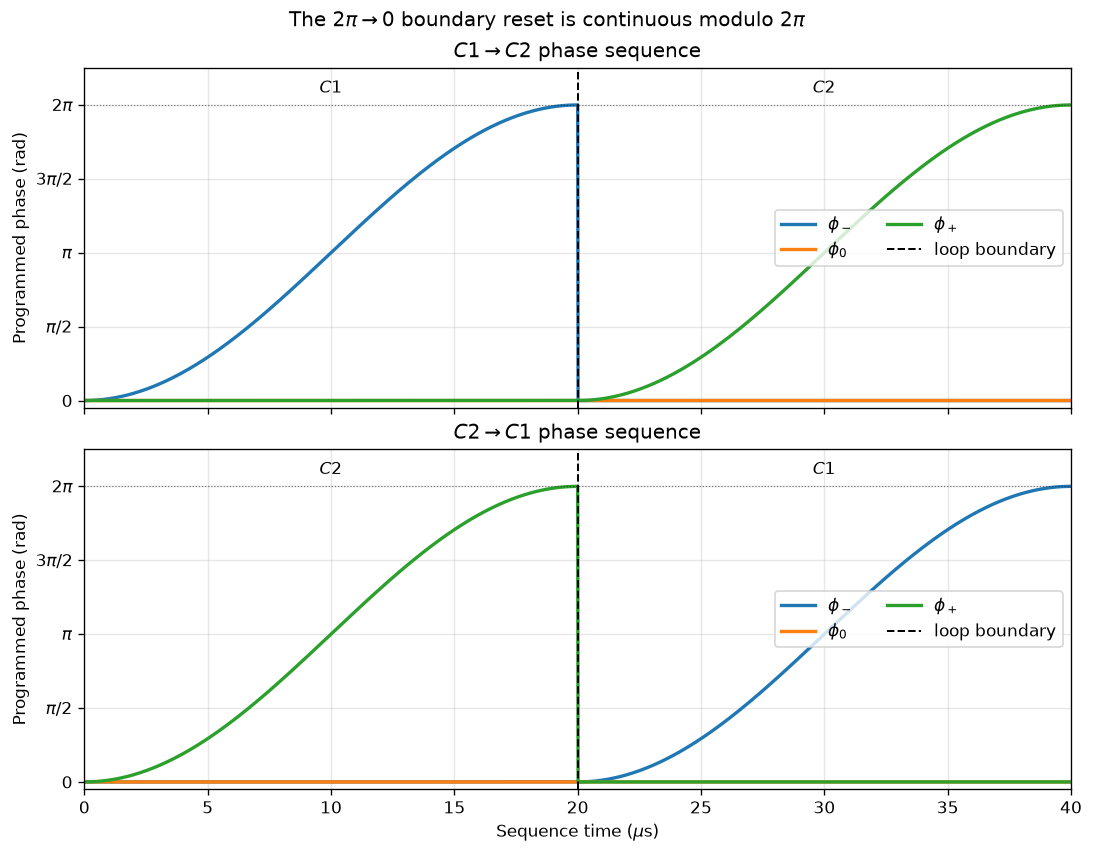

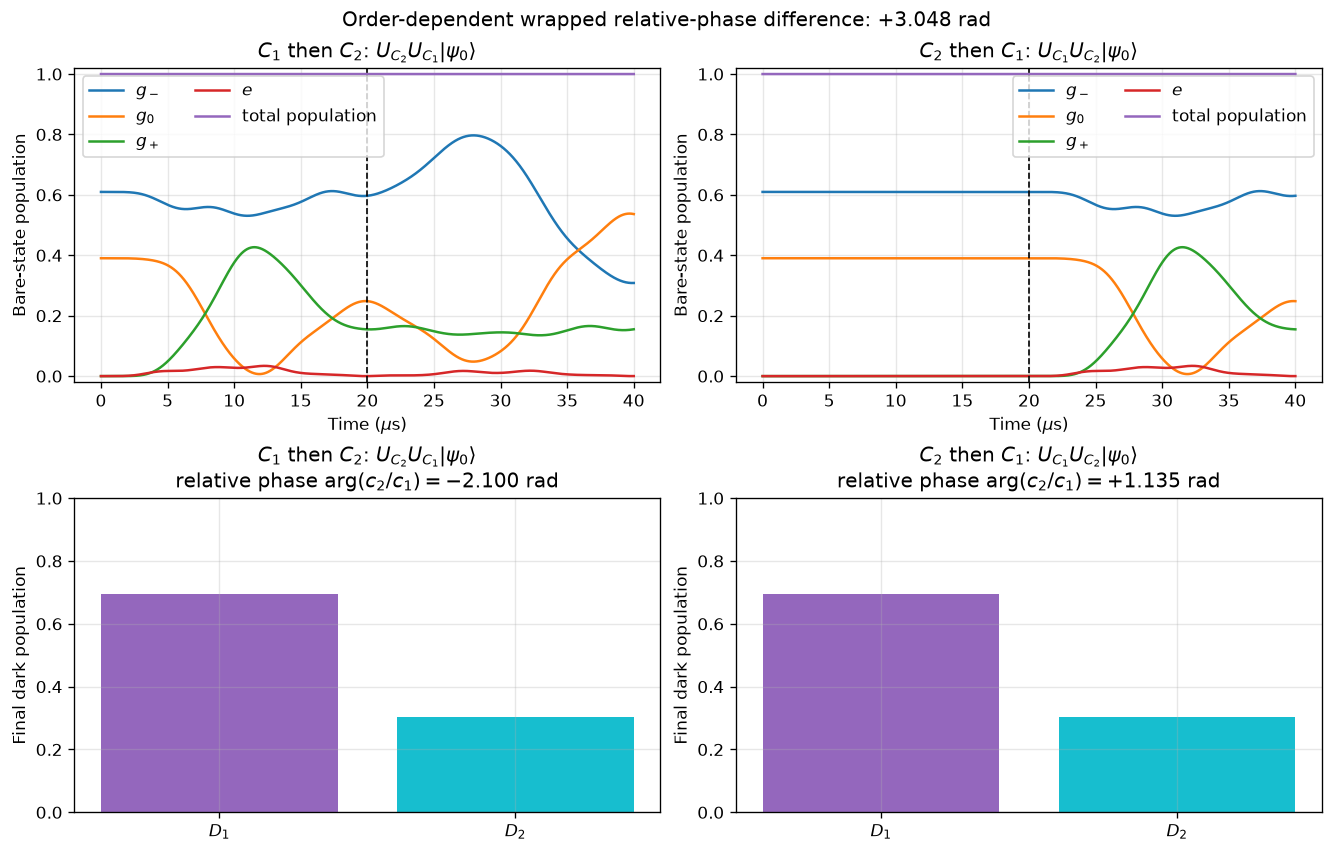

In [17]:
def plot_order_comparison(comparison):
    '''Plot the two consecutive-loop histories and their final dark-basis populations.'''
    fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
    sequence_keys = ("C1_then_C2", "C2_then_C1")
    titles = (r"$C_1$ then $C_2$: $U_{C_2}U_{C_1}|\psi_0\rangle$",
              r"$C_2$ then $C_1$: $U_{C_1}U_{C_2}|\psi_0\rangle$")
    for ax, key, title in zip(axes[0], sequence_keys, titles):
        result = comparison[key]
        total_population = np.zeros_like(result["populations"][0])
        for population, label in zip(result["populations"], state_labels):
            ax.plot(result["time_us"], population, label=label)
            total_population += population
        ax.plot(result["time_us"], total_population, label="total population")
        boundary = result["experiments"][0].total_time
        ax.axvline(boundary, color="k", ls="--", lw=1)
        ax.set(title=title, xlabel=r"Time ($\mu$s)", ylabel="Bare-state population",
               ylim=(-0.02, 1.02))
        ax.legend(ncol=2)

    x = np.arange(2)
    for ax, suffix, title in zip(
        axes[1], ("C1_then_C2", "C2_then_C1"), titles
    ):
        amplitudes = comparison[f"dark_amplitudes_{suffix}"]
        relative_phase = comparison[f"relative_phase_{suffix}"]
        ax.bar(x, np.abs(amplitudes)**2, color=("tab:purple", "tab:cyan"))
        ax.set(xticks=x, xticklabels=(r"$D_1$", r"$D_2$"), ylabel="Final dark population",
               title=title + "\n" + rf"relative phase $\arg(c_2/c_1)={relative_phase:+.3f}$ rad",
               ylim=(0, 1))
    phase_12 = comparison["relative_phase_C1_then_C2"]
    phase_21 = comparison["relative_phase_C2_then_C1"]
    phase_difference = np.angle(np.exp(1j * (phase_12 - phase_21)))
    fig.suptitle(rf"Order-dependent wrapped relative-phase difference: ${phase_difference:+.3f}$ rad")
    return fig, axes


OMEGA_LEGS_MHZ = (0.16, 0.20, 0.24)  # deliberately unequal
PHASES = loop_phases(t_us=0.0, loop_time_us=20.0, loop="C1")

init_state = 'D1'
INITIAL_STATE = choose_init_state(init_state, OMEGA_LEGS_MHZ, PHASES)

print(f"===== Checking orthoganality of states =====")
B = tripod_bright_state(OMEGA_LEGS_MHZ, PHASES)
D1, D2 = tripod_dark_states(OMEGA_LEGS_MHZ, PHASES)
print(f'<B|D1> = {B.dag() * D1}')
print(f'<B|D2> = {B.dag() * D2}')
print(f'<D2|D1> = {D2.dag() * D1}')
print(f"============================================\n")

print(f"===== Choosing initial state {init_state} =====\n")


order_comparison = compare_loop_orders(INITIAL_STATE, OMEGA_LEGS_MHZ, loop_time_us=20.0, display_phase_plots=True)
order_fig, order_axes = plot_order_comparison(order_comparison)

phase_12 = order_comparison["relative_phase_C1_then_C2"]
phase_21 = order_comparison["relative_phase_C2_then_C1"]
phase_difference = np.angle(np.exp(1j * (phase_12 - phase_21)))
print(f"relative dark phase, C1 then C2 = {phase_12:+.4f} rad")
print(f"relative dark phase, C2 then C1 = {phase_21:+.4f} rad")
print(f"wrapped phase difference          = {phase_difference:+.4f} rad")
print(f"P(g-) order-swap contrast         = {order_comparison['order_swap_contrast_g_minus']:.4f}")
print(f"final-state fidelity              = {order_comparison['final_state_fidelity']:.4f}")

## Reconstructing the dark-space maps

A relative phase from one input state is useful but is not a complete non-Abelian test. Each loop acts as a $2\times2$ matrix inside the dark subspace. The next cells propagate both $|D_1\rangle$ and $|D_2\rangle$, construct

$$M(C)_{ab}=\langle D_a(0)|U_C|D_b(0)\rangle,$$

extract the closest unitary by polar decomposition, and evaluate
$\|[U_D(C_2),U_D(C_1)]\|_F$. A nonzero commutator is the basis-independent order-dependence signature sought here.

In [18]:
from scipy.linalg import expm


PHASE_COORDINATES = ("-", "0", "+")


def wilczek_zee_connection(omega_legs_mhz, phases, derivative_step=1e-6):
    '''
    Calculate all three matrix-valued components A_alpha explicitly.

    alpha in {-, 0, +} labels the phase coordinate phi_alpha, while
    a,b in {1,2} label dark basis vectors:

        (A_alpha)_ab = <D_a | partial_{phi_alpha} D_b>.

    Central differences evaluate the derivatives of the analytic dark states.
    The returned array has shape (3, 2, 2): A[alpha, a, b].
    '''
    phases = np.asarray(phases, dtype=float)
    dark_basis = tripod_dark_states(omega_legs_mhz, phases)
    A = np.empty((3, 2, 2), dtype=complex)

    for alpha in range(3):
        phases_plus = phases.copy()
        phases_minus = phases.copy()
        phases_plus[alpha] += derivative_step
        phases_minus[alpha] -= derivative_step

        dark_plus = tripod_dark_states(omega_legs_mhz, phases_plus)
        dark_minus = tripod_dark_states(omega_legs_mhz, phases_minus)
        derivatives = [
            (dark_plus[b] - dark_minus[b]) / (2 * derivative_step)
            for b in range(2)
        ]

        # Explicitly calculate every element (A_alpha)_{ab}.
        for a in range(2):
            for b in range(2):
                A[alpha, a, b] = dark_basis[a].overlap(derivatives[b])

    return {
        coordinate: A[alpha]
        for alpha, coordinate in enumerate(PHASE_COORDINATES)
    }


def print_connection_components(omega_legs_mhz, phases=(0.0, 0.0, 0.0)):
    '''Print A_-, A_0, and A_+ at one point on the control path.'''
    connection = wilczek_zee_connection(omega_legs_mhz, phases)
    for coordinate in PHASE_COORDINATES:
        print(f"A_{coordinate} =")
        print(np.round(connection[coordinate], 6))
        print()
    return connection


def phase_path(s, loop):
    '''Closed control-space path parameterized by s=t/T in [0,1].'''
    # Reuse the exact same phase definition as the Rabi Hamiltonian.
    return loop_phases(t_us=s, loop_time_us=1.0, loop=loop)


def phase_path_derivative(s, loop):
    '''d(phi_-,phi_0,phi_+)/ds for the smooth phase winding.'''
    derivative = np.zeros(3)
    wound_coordinate = 0 if loop == "C1" else 2
    derivative[wound_coordinate] = np.pi**2 * np.sin(np.pi * s)
    return derivative


def geometric_holonomy(loop, omega_legs_mhz, path_steps=4000, derivative_step=1e-6):
    r'''
    Evaluate Eq. (7): U(C) = P exp[-integral A_alpha d(lambda_alpha)].

    Midpoint path ordering is implemented by multiplying each infinitesimal
    exponential on the left. The result acts on dark-state coefficient columns.
    '''
    if loop not in {"C1", "C2"}:
        raise ValueError("loop must be 'C1' or 'C2'")

    ds = 1.0 / path_steps
    holonomy = np.eye(2, dtype=complex)

    for step in range(path_steps):
        s_mid = (step + 0.5) * ds
        phases = phase_path(s_mid, loop)
        dphase_ds = phase_path_derivative(s_mid, loop)
        connection = wilczek_zee_connection(
            omega_legs_mhz, phases, derivative_step=derivative_step
        )

        # Pull back the connection vector onto this one-dimensional path:
        # A_s = sum_alpha A_alpha * d(phi_alpha)/ds.
        A_along_path = sum(
            connection[coordinate] * dphase_ds[alpha]
            for alpha, coordinate in enumerate(PHASE_COORDINATES)
        )
        holonomy = expm(-A_along_path * ds) @ holonomy

    return holonomy


connection_at_origin = print_connection_components(OMEGA_LEGS_MHZ)

A_- =
[[0.-0.390244j 0.+0.333543j]
 [0.+0.333543j 0.+0.182452j]]

A_0 =
[[0.-0.609756j 0.-0.333543j]
 [0.-0.333543j 0.+0.285081j]]

A_+ =
[[0.+0.j       0.+0.j      ]
 [0.+0.j       0.-0.467532j]]



In [19]:
U_C1 = geometric_holonomy("C1", OMEGA_LEGS_MHZ)
U_C2 = geometric_holonomy("C2", OMEGA_LEGS_MHZ)

# Requested convention: U(C1)U(C2) - U(C2)U(C1).
commutator_matrix = U_C1 @ U_C2 - U_C2 @ U_C1
commutator_norm = np.linalg.norm(commutator_matrix, ord="fro")

print("U(C1) =")
print(np.round(U_C1, 6))
print("\nU(C2) =")
print(np.round(U_C2, 6))
print("\nU(C1)U(C2) - U(C2)U(C1) =")
print(np.round(commutator_matrix, 6))
print(f"\ncommutator Frobenius norm = {commutator_norm:.6f}")
print(f"U(C1) unitarity error = {np.linalg.norm(U_C1.conj().T @ U_C1 - np.eye(2)):.3e}")
print(f"U(C2) unitarity error = {np.linalg.norm(U_C2.conj().T @ U_C2 - np.eye(2)):.3e}")

U(C1) =
[[ 0.432045+0.742784j -0.310677+0.406311j]
 [-0.310677+0.406311j  0.830056+0.222256j]]

U(C2) =
[[ 1.      +0.j        0.      +0.j      ]
 [ 0.      +0.j       -0.979264+0.202587j]]

U(C1)U(C2) - U(C2)U(C1) =
[[ 0.      +0.j        0.532599-0.867136j]
 [-0.532599+0.867136j -0.      -0.j      ]]

commutator Frobenius norm = 1.439157
U(C1) unitarity error = 3.038e-12
U(C2) unitarity error = 1.975e-12


# Additional plots

## Geometric connection versus finite-time `Rabi` evolution

Equation (7) reconstructs the **ideal adiabatic holonomy** directly from the Wilczek-Zee connection. The connection is a vector over the three phase coordinates,

$$\mathbf A=(A_-,A_0,A_+),\qquad
(A_\alpha)_{ab}=\langle D_a|\partial_{\phi_\alpha}D_b\rangle.$$

Each $A_\alpha$ depends on the instantaneous amplitudes and phases that define the dark basis, but it does not depend on how quickly those controls are traversed. In physical time, the connection pulled onto the trajectory is

$$A_t(t)=\sum_\alpha A_\alpha[\boldsymbol\phi(t)]\,\dot\phi_\alpha(t),$$

and the holonomy is

$$U(C)=\mathcal P\exp\left[-\int_0^T A_t(t)\,dt\right].$$

Writing $s=t/T$ gives $\dot\phi_\alpha=(1/T)d\phi_\alpha/ds$ and $dt=Tds$. The two factors of $T$ cancel:

$$\int_0^T A_t(t)dt
=\int_0^1\sum_\alpha A_\alpha[\boldsymbol\phi(s)]
\frac{d\phi_\alpha}{ds}ds.$$

This is why the Eq. (7) commutator has no explicit loop-time dependence: it depends on the oriented path in control space, not the traversal speed.

The `Rabi` simulation solves the full finite-time Schrodinger equation. It uses the same `loop_phases()` function, but it affects the result only when the adiabatic approximation is imperfect. At finite $T$, the simulated state can enter the bright/ancilla sector, and its effective final dark-space action differs from the ideal $U(C)$. The leakage curves below quantify this discrepancy. Recovering a time-dependent **finite-speed commutator** would require projecting the full Rabi evolution back into the dark space (the earlier $M(C,T)$ procedure); it cannot be obtained from Eq. (7) alone.

In [20]:
def scan_geometric_path_resolution(
    path_steps_values,
    omega_legs_mhz=(0.20, 0.20, 0.20),
):
    '''Show convergence of Eq. (7) as the path-ordering discretization is refined.'''
    path_steps_values = np.asarray(path_steps_values, dtype=int)
    commutator_norms = np.empty(len(path_steps_values))
    unitarity_errors = np.empty(len(path_steps_values))

    for index, path_steps in enumerate(path_steps_values):
        U_C1 = geometric_holonomy("C1", omega_legs_mhz, path_steps=path_steps)
        U_C2 = geometric_holonomy("C2", omega_legs_mhz, path_steps=path_steps)
        commutator = U_C1 @ U_C2 - U_C2 @ U_C1
        commutator_norms[index] = np.linalg.norm(commutator, ord="fro")
        unitarity_errors[index] = max(
            np.linalg.norm(U_C1.conj().T @ U_C1 - np.eye(2), ord="fro"),
            np.linalg.norm(U_C2.conj().T @ U_C2 - np.eye(2), ord="fro"),
        )

    return {
        "path_steps": path_steps_values,
        "commutator_norms": commutator_norms,
        "unitarity_errors": unitarity_errors,
        "omega_legs_mhz": tuple(omega_legs_mhz),
    }

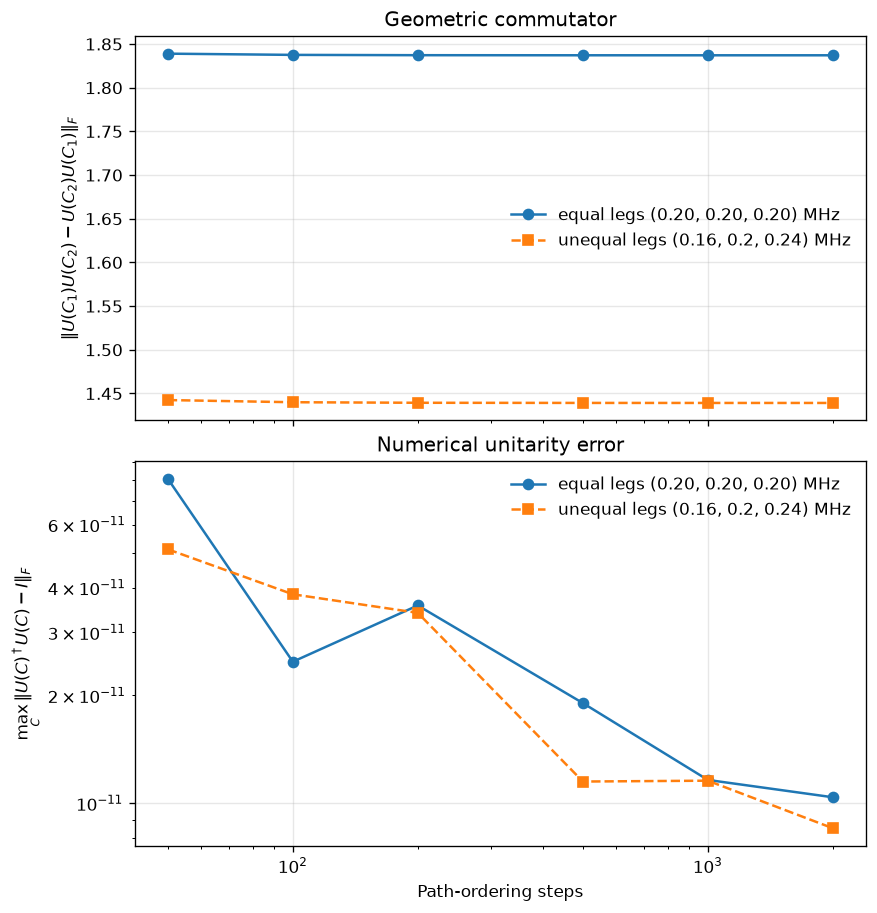

In [21]:
def plot_geometric_convergence(equal_scan, unequal_scan=None):
    '''Plot numerical convergence of the direct Eq. (7) calculation.'''
    fig, axes = plt.subplots(2, 1, figsize=(7.2, 7.5), sharex=True, constrained_layout=True)

    for scan, label, style in [
        (equal_scan, "equal legs (0.20, 0.20, 0.20) MHz", "o-"),
        (unequal_scan, f"unequal legs {OMEGA_LEGS_MHZ} MHz", "s--"),
    ]:
        if scan is None:
            continue
        axes[0].semilogx(scan["path_steps"], scan["commutator_norms"], style, label=label)
        axes[1].loglog(scan["path_steps"], scan["unitarity_errors"], style, label=label)

    axes[0].set(ylabel=r"$\|U(C_1)U(C_2)-U(C_2)U(C_1)\|_F$", title="Geometric commutator")
    axes[1].set(xlabel="Path-ordering steps", ylabel=r"$\max_C\|U(C)^\dagger U(C)-I\|_F$",
                title="Numerical unitarity error")
    axes[0].legend(frameon=False)
    axes[1].legend(frameon=False)
    return fig, axes


PATH_STEPS_SCAN = np.array([50, 100, 200, 500, 1000, 2000])
geometric_equal = scan_geometric_path_resolution(
    PATH_STEPS_SCAN, omega_legs_mhz=(0.20, 0.20, 0.20)
)
geometric_unequal = scan_geometric_path_resolution(
    PATH_STEPS_SCAN, omega_legs_mhz=OMEGA_LEGS_MHZ
)
geometric_convergence_fig, geometric_convergence_axes = plot_geometric_convergence(
    geometric_equal, geometric_unequal
)

## Simulated adiabatic leakage from the `Rabi` trajectories

The analytic curve in Fig. 1 uses $\max|\dot\phi|=\pi^2/T$ and estimates the scaling

$$P_{\rm ad}^{(\rm est)}\sim\left(\frac{\pi^2}{T\Omega_{\rm tot}}\right)^2.$$

It does not inspect the evolved state. The `Rabi` calculation gives the full state $\rho(t)$, so we can instead construct the instantaneous dark projector

$$\Pi_D(t)=|D_1(t)\rangle\langle D_1(t)|+|D_2(t)\rangle\langle D_2(t)|$$

and calculate the simulated leakage

$$P_{\rm leak}(t)=1-\operatorname{Tr}[\Pi_D(t)\rho(t)].$$

This contains both ancilla population $P_e(t)$ and population in the instantaneous bright ground-state combination $P_B(t)$. The paper's directly measurable proxy is $\max_tP_e(t)$, whereas $\max_tP_{\rm leak}(t)$ is the more complete numerical measure.

In [22]:
def state_expectation(projector, state):
    '''Expectation value for either a ket or density matrix.'''
    if state.isket:
        return float(np.real(state.dag() * projector * state))
    return float(np.real((projector * state).tr()))


def instantaneous_dark_leakage(experiment, loop, omega_legs_mhz, loop_time_us):
    '''Decompose each simulated state into dark, bright, and ancilla populations.'''
    dark_population = []
    ancilla_population = []
    ancilla_projector = ket2dm(ancilla)

    for t_us, state in zip(experiment.variable, experiment.rho):
        phases = loop_phases(t_us, loop_time_us, loop)
        d1, d2 = tripod_dark_states(omega_legs_mhz, phases)
        dark_projector = ket2dm(d1) + ket2dm(d2)
        dark_population.append(state_expectation(dark_projector, state))
        ancilla_population.append(state_expectation(ancilla_projector, state))

    dark_population = np.asarray(dark_population)
    ancilla_population = np.asarray(ancilla_population)
    total_leakage = np.clip(1.0 - dark_population, 0.0, 1.0)
    # total_leakage = np.clip(dark_population, 0.0, 1.0)

    bright_population = np.clip(total_leakage - ancilla_population, 0.0, 1.0)

    return {
        "time_us": np.asarray(experiment.variable),
        "dark_population": dark_population,
        "total_leakage": total_leakage,
        "ancilla_population": ancilla_population,
        "bright_population": bright_population,
        "maximum_total_leakage": float(np.max(total_leakage)),
        "maximum_ancilla_population": float(np.max(ancilla_population)),
        "final_total_leakage": float(total_leakage[-1]),
    }

maximum total dark-space leakage = 0.03756
maximum ancilla population       = 0.03396
final dark-space leakage         = 1.34489e-03


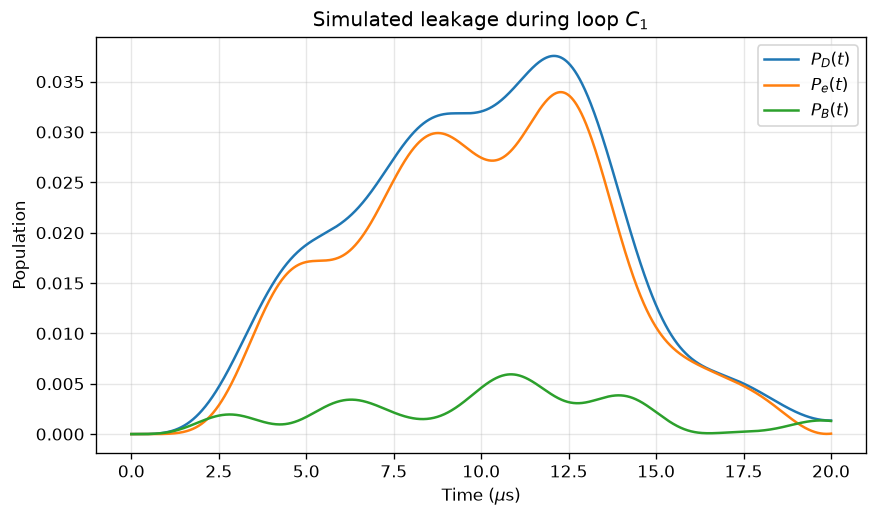

In [23]:
def plot_leakage_trajectory(leakage, loop):
    '''Plot the leakage decomposition for one simulated phase-winding loop.'''
    fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
    ax.plot(leakage["time_us"], leakage["total_leakage"], label=r"$P_D(t)$")
    ax.plot(leakage["time_us"], leakage["ancilla_population"], label=r"$P_e(t)$")
    ax.plot(leakage["time_us"], leakage["bright_population"], label=r"$P_B(t)$")
    ax.set(
        xlabel=r"Time ($\mu$s)", ylabel="Population",
        title=rf"Simulated leakage during loop ${loop}$",
    )
    ax.legend()
    return fig, ax


leakage_example_time_us = 20.0
leakage_initial_state = tripod_dark_states(OMEGA_LEGS_MHZ)[0]
leakage_experiment = build_tripod_rabi(
    loop="C1", rho0=leakage_initial_state,
    loop_time_us=leakage_example_time_us,
    omega_legs_mhz=OMEGA_LEGS_MHZ,
)
leakage_experiment.run()
leakage_example = instantaneous_dark_leakage(
    leakage_experiment, "C1", OMEGA_LEGS_MHZ, leakage_example_time_us
)
leakage_trajectory_fig, leakage_trajectory_ax = plot_leakage_trajectory(
    leakage_example, "C_1"
)
print(f"maximum total dark-space leakage = {leakage_example['maximum_total_leakage']:.5f}")
print(f"maximum ancilla population       = {leakage_example['maximum_ancilla_population']:.5f}")
print(f"final dark-space leakage         = {leakage_example['final_total_leakage']:.5e}")

In [24]:
def scan_simulated_leakage(
    loop_times_us,
    loop="C1",
    omega_legs_mhz=(0.16, 0.20, 0.24),
    samples=801,
):
    '''Run a separate Rabi trajectory at every T and extract simulated leakage.'''
    loop_times_us = np.asarray(loop_times_us, dtype=float)
    maximum_total = np.empty_like(loop_times_us)
    maximum_ancilla = np.empty_like(loop_times_us)
    final_total = np.empty_like(loop_times_us)
    initial_state = tripod_dark_states(omega_legs_mhz)[0]

    for index, loop_time_us in enumerate(loop_times_us):
        experiment = build_tripod_rabi(
            loop=loop, rho0=initial_state, loop_time_us=loop_time_us,
            omega_legs_mhz=omega_legs_mhz, samples=samples,
        )
        experiment.run()
        leakage = instantaneous_dark_leakage(
            experiment, loop, omega_legs_mhz, loop_time_us
        )
        maximum_total[index] = leakage["maximum_total_leakage"]
        maximum_ancilla[index] = leakage["maximum_ancilla_population"]
        final_total[index] = leakage["final_total_leakage"]

    return {
        "loop_times_us": loop_times_us,
        "maximum_total_leakage": maximum_total,
        "maximum_ancilla_population": maximum_ancilla,
        "final_total_leakage": final_total,
        "loop": loop,
        "omega_legs_mhz": tuple(omega_legs_mhz),
    }

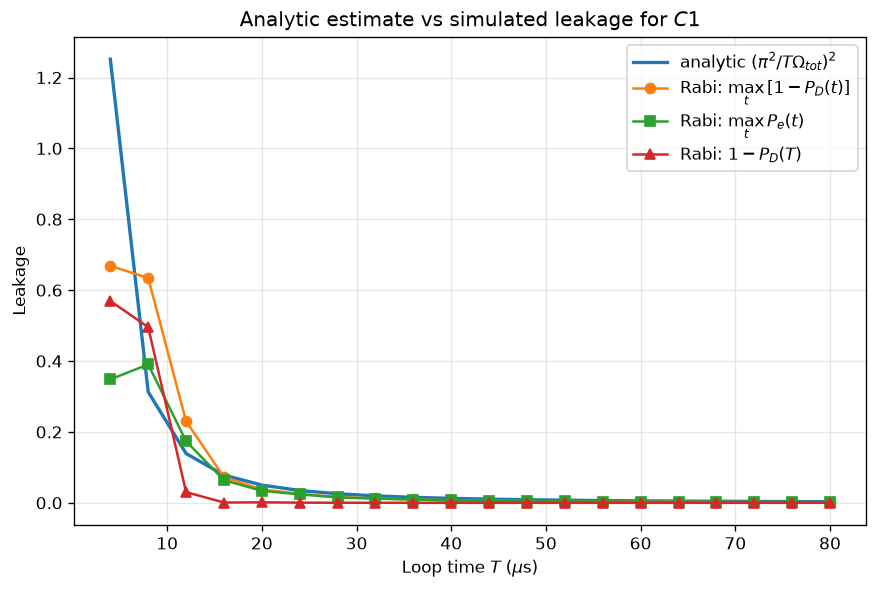

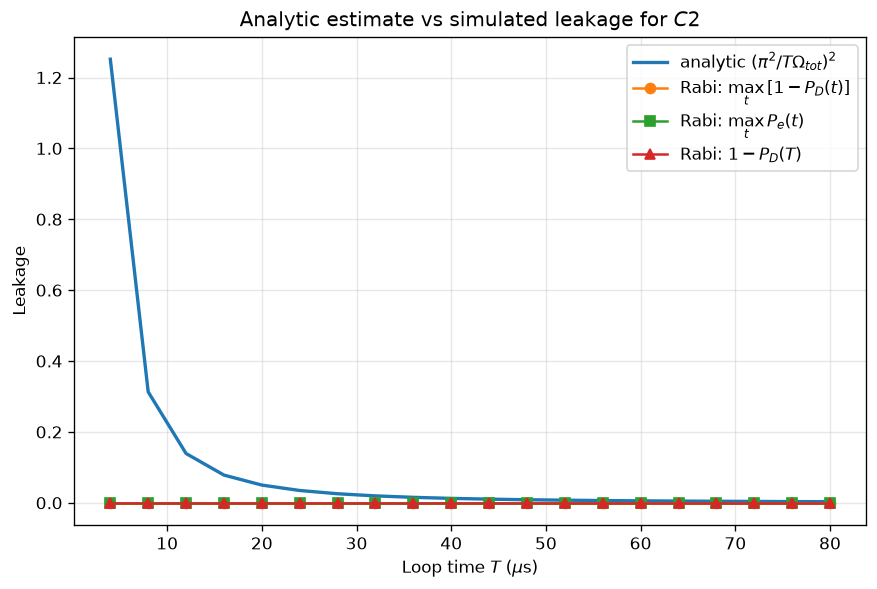

In [25]:
def plot_analytic_vs_simulated_leakage(simulated):
    '''Compare the analytic scaling estimate with leakage extracted from Rabi states.'''
    times = simulated["loop_times_us"]
    omegas = simulated["omega_legs_mhz"]
    omega_tot_rad_per_us = 2 * np.pi * omega_total(omegas)
    analytic = (np.pi**2 / (times * omega_tot_rad_per_us)) ** 2

    fig, ax = plt.subplots(figsize=(7.2, 4.8), constrained_layout=True)
    ax.plot(times, analytic, lw=2, label=r"analytic $(\pi^2/T\Omega_{tot})^2$")
    ax.plot(times, simulated["maximum_total_leakage"], "o-",
              label=r"Rabi: $\max_t[1-P_D(t)]$")
    ax.plot(times, simulated["maximum_ancilla_population"], "s-",
              label=r"Rabi: $\max_tP_e(t)$")
    ax.plot(times, simulated["final_total_leakage"], "^-",
              label=r"Rabi: $1-P_D(T)$")
    ax.set(
        xlabel=r"Loop time $T$ ($\mu$s)", ylabel="Leakage",
        title=rf"Analytic estimate vs simulated leakage for ${simulated['loop']}$",
    )
    ax.legend()
    return fig, ax


LEAKAGE_SCAN_TIMES_US = np.arange(4.0, 82.0, 4.0)
simulated_leakage_C1 = scan_simulated_leakage(
    LEAKAGE_SCAN_TIMES_US, loop="C1", omega_legs_mhz=OMEGA_LEGS_MHZ
)
simulated_leakage_C2 = scan_simulated_leakage(
    LEAKAGE_SCAN_TIMES_US, loop="C2", omega_legs_mhz=OMEGA_LEGS_MHZ
)
leakage_scan_fig_C1, leakage_scan_ax_C1 = plot_analytic_vs_simulated_leakage(
    simulated_leakage_C1
)
leakage_scan_fig_C2, leakage_scan_ax_C2 = plot_analytic_vs_simulated_leakage(
    simulated_leakage_C2
)

## Figure 1 - timing trade-off for arbitrary leg amplitudes

For unequal legs the bright-dark scale is

$$\Omega_{\rm tot}=\sqrt{\Omega_-^2+\Omega_0^2+\Omega_+^2},$$

not $\sqrt{3}\Omega_{\rm leg}$. The factor $2\pi$ below converts MHz (cycles per microsecond) to angular frequency (radians per microsecond) because Eq. (13) is written using angular frequencies.

In [26]:
def adiabatic_leakage_estimate(loop_time_us, omega_legs_mhz=(0.16, 0.20, 0.24)):
    '''Equation (13) for arbitrary tripod leg amplitudes.'''
    loop_time_us = np.asarray(loop_time_us, dtype=float)
    omega_tot_rad_per_us = 2 * np.pi * omega_total(omega_legs_mhz)
    return (np.pi**2 / (loop_time_us * omega_tot_rad_per_us)) ** 2


def visibility_proxy(loop_time_us, t2rho_us, omega_legs_mhz=(0.16, 0.20, 0.24)):
    '''Phenomenological visibility, clipping the estimate before using it as a probability.'''
    p_ad = np.clip(adiabatic_leakage_estimate(loop_time_us, omega_legs_mhz), 0.0, 1.0)
    return np.exp(-np.asarray(loop_time_us) / t2rho_us) * (1.0 - p_ad)

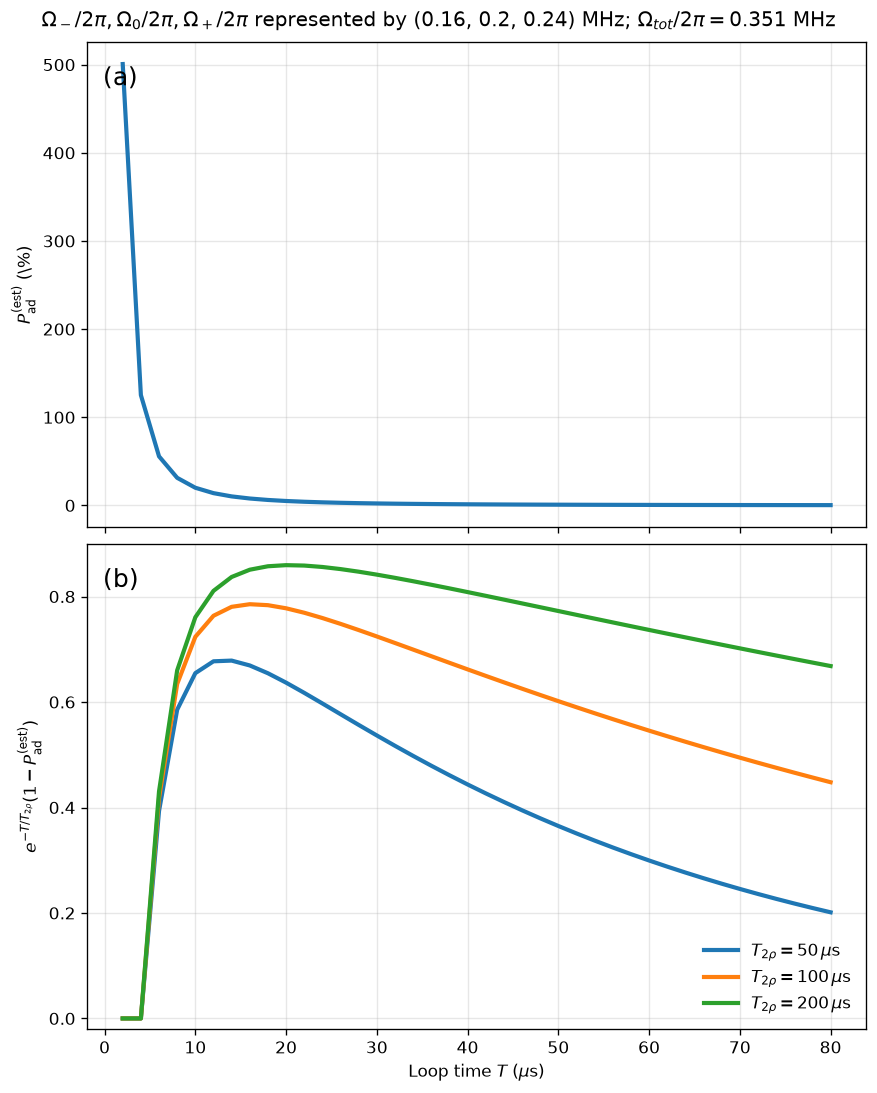

In [27]:
def plot_figure_1(
    omega_legs_mhz=(0.16, 0.20, 0.24),
    t2rho_values_us=(50.0, 100.0, 200.0),
):
    '''Produce both Fig. 1 panels for any three leg amplitudes.'''
    omega_legs_mhz = validate_omega_legs(omega_legs_mhz)
    loop_times_us = np.arange(2.0, 82.0, 2.0)
    p_ad = adiabatic_leakage_estimate(loop_times_us, omega_legs_mhz)

    fig, axes = plt.subplots(2, 1, figsize=(7.2, 9.0), sharex=True, constrained_layout=True)
    axes[0].plot(loop_times_us, 100.0 * p_ad, lw=2.5)
    axes[0].set_ylabel(r"$P_{\rm ad}^{(\rm est)}$ (\%)")
    axes[0].text(0.02, 0.95, "(a)", transform=axes[0].transAxes, va="top", fontsize=15)

    for t2rho_us in t2rho_values_us:
        axes[1].plot(
            loop_times_us,
            visibility_proxy(loop_times_us, t2rho_us, omega_legs_mhz),
            lw=2.5,
            label=rf"$T_{{2\rho}}={t2rho_us:g}\,\mu\mathrm{{s}}$",
        )
    axes[1].set(
        xlabel=r"Loop time $T$ ($\mu$s)",
        ylabel=r"$e^{-T/T_{2\rho}}(1-P_{\rm ad}^{(\rm est)})$",
        ylim=(-0.02, 0.90),
    )
    axes[1].text(0.02, 0.95, "(b)", transform=axes[1].transAxes, va="top", fontsize=15)
    axes[1].legend(loc="lower right", frameon=False)
    fig.suptitle(
        rf"$\Omega_-/2\pi,\Omega_0/2\pi,\Omega_+/2\pi$ represented by "
        rf"{tuple(float(value) for value in omega_legs_mhz)} MHz; "
        rf"$\Omega_{{tot}}/2\pi={omega_total(omega_legs_mhz):.3f}$ MHz"
    )
    return fig, axes


fig_1, fig_1_axes = plot_figure_1(OMEGA_LEGS_MHZ)

In [28]:
# Numerical consistency checks.
assert np.isclose(omega_total((0.20, 0.20, 0.20)), np.sqrt(3) * 0.20)
assert np.isclose(omega_total(OMEGA_LEGS_MHZ), np.sqrt(np.sum(np.square(OMEGA_LEGS_MHZ))))
assert np.all(np.diff(adiabatic_leakage_estimate(np.arange(2.0, 82.0, 2.0), OMEGA_LEGS_MHZ)) < 0)
assert 0.0 <= visibility_proxy(20.0, 50.0, OMEGA_LEGS_MHZ) <= 1.0

print(f"unequal legs (MHz)      = {OMEGA_LEGS_MHZ}")
print(f"Omega_tot / 2pi (MHz)   = {omega_total(OMEGA_LEGS_MHZ):.4f}")
print(f"P_ad(est) at T=20 us    = {100*adiabatic_leakage_estimate(20.0, OMEGA_LEGS_MHZ):.2f}%")

unequal legs (MHz)      = (0.16, 0.2, 0.24)
Omega_tot / 2pi (MHz)   = 0.3510
P_ad(est) at T=20 us    = 5.01%
